# Data Exploration
## ASL Sign Language Translator
This notebook explores the dataset, visualizes class distribution,
and shows hand landmark points extracted by MediaPipe.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import mediapipe as mp
import os

print("All libraries imported successfully!")

All libraries imported successfully!


In [8]:
df = pd.read_csv('E:/asl/data/landmarks/landmarks_clean.csv')

print(f"Total rows:    {len(df)}")
print(f"Total columns: {len(df.columns)}")
print(f"Total classes: {df['label'].nunique()}")
print(f"\nFirst 5 rows:")
df.head()

Total rows:    34103
Total columns: 43
Total classes: 25

First 5 rows:


,0,1,2,3,4,5,6,7,8,9,...,33,34,35,36,37,38,39,40,41,label
0,0.0,0.0,0.274222,-0.175749,0.439442,-0.497523,0.444134,-0.773115,0.434750,-1.000000,...,-0.330189,-0.301959,-0.528023,-0.247031,-0.658881,-0.201128,-0.474233,-0.173414,-0.328293,A
1,0.0,0.0,0.365349,-0.041646,0.681685,-0.303275,0.773013,-0.604015,0.755178,-0.860101,...,-0.340227,-0.207811,-0.630964,-0.226987,-0.676431,-0.206217,-0.461696,-0.175135,-0.346736,A
2,0.0,0.0,0.254959,-0.224309,0.402614,-0.514230,0.417448,-0.776931,0.388393,-1.000000,...,-0.463187,-0.283645,-0.552079,-0.302193,-0.695523,-0.238886,-0.529837,-0.204861,-0.422422,A
3,0.0,0.0,0.362665,0.007501,0.645587,-0.362490,0.711510,-0.736013,0.653218,-0.992499,...,-0.258984,-0.283524,-0.565091,-0.230520,-0.717872,-0.231960,-0.450740,-0.228427,-0.280798,A
4,0.0,0.0,0.255884,-0.218870,0.425506,-0.536163,0.392502,-0.794162,0.296588,-1.000000,...,-0.358906,-0.376957,-0.503168,-0.316229,-0.674193,-0.233060,-0.478005,-0.189249,-0.315900,A


## Chart 1 — Class Distribution
How many samples does each letter have?

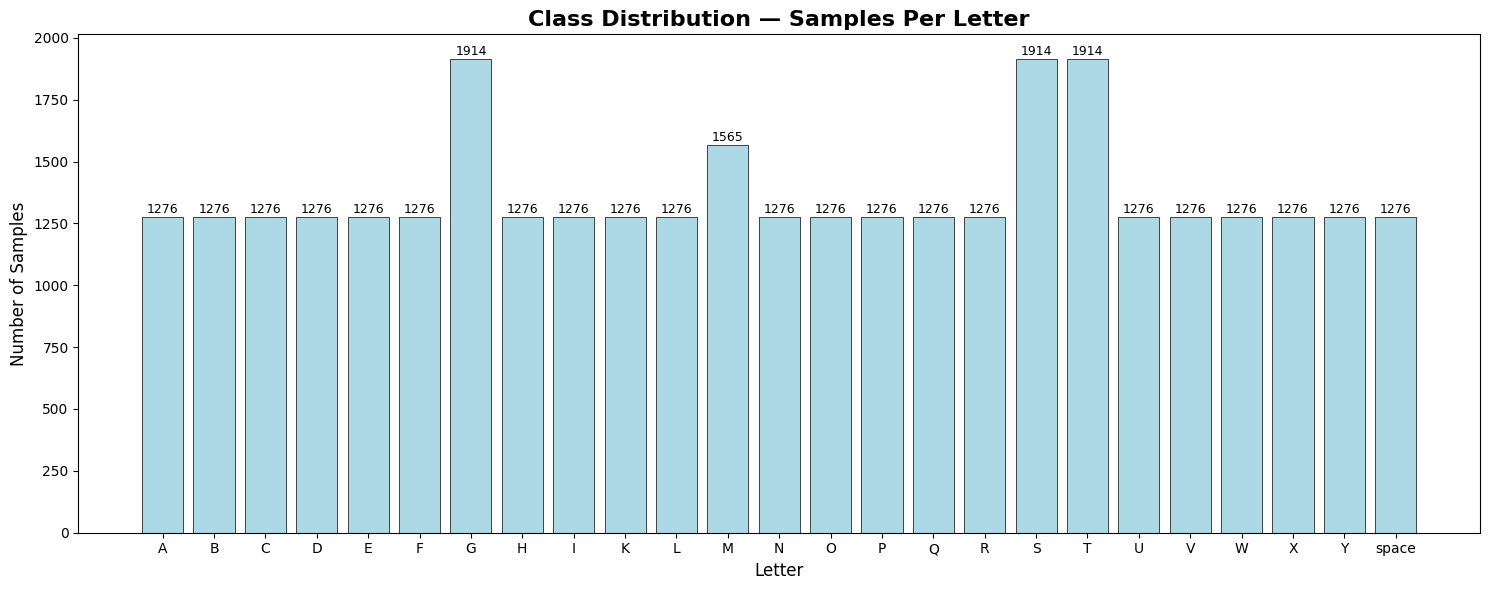

Min samples: 1276 — Max samples: 1914


In [9]:
plt.figure(figsize=(15, 6))

counts = df['label'].value_counts().sort_index()

colors = sns.color_palette("husl", len(counts))

bars = plt.bar(counts.index, counts.values, color='lightblue', edgecolor='black', linewidth=0.5)

for bar, count in zip(bars, counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        str(count),
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.title('Class Distribution — Samples Per Letter', fontsize=16, fontweight='bold')
plt.xlabel('Letter', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)
plt.ylim(0, max(counts.values) + 100)
plt.tight_layout()
plt.savefig('../data/processed/class_distribution.png', dpi=150)
plt.show()

print(f"Min samples: {counts.min()} — Max samples: {counts.max()}")

## Chart 2 — Sample Images From Dataset
Let's look at actual gesture images from the dataset.

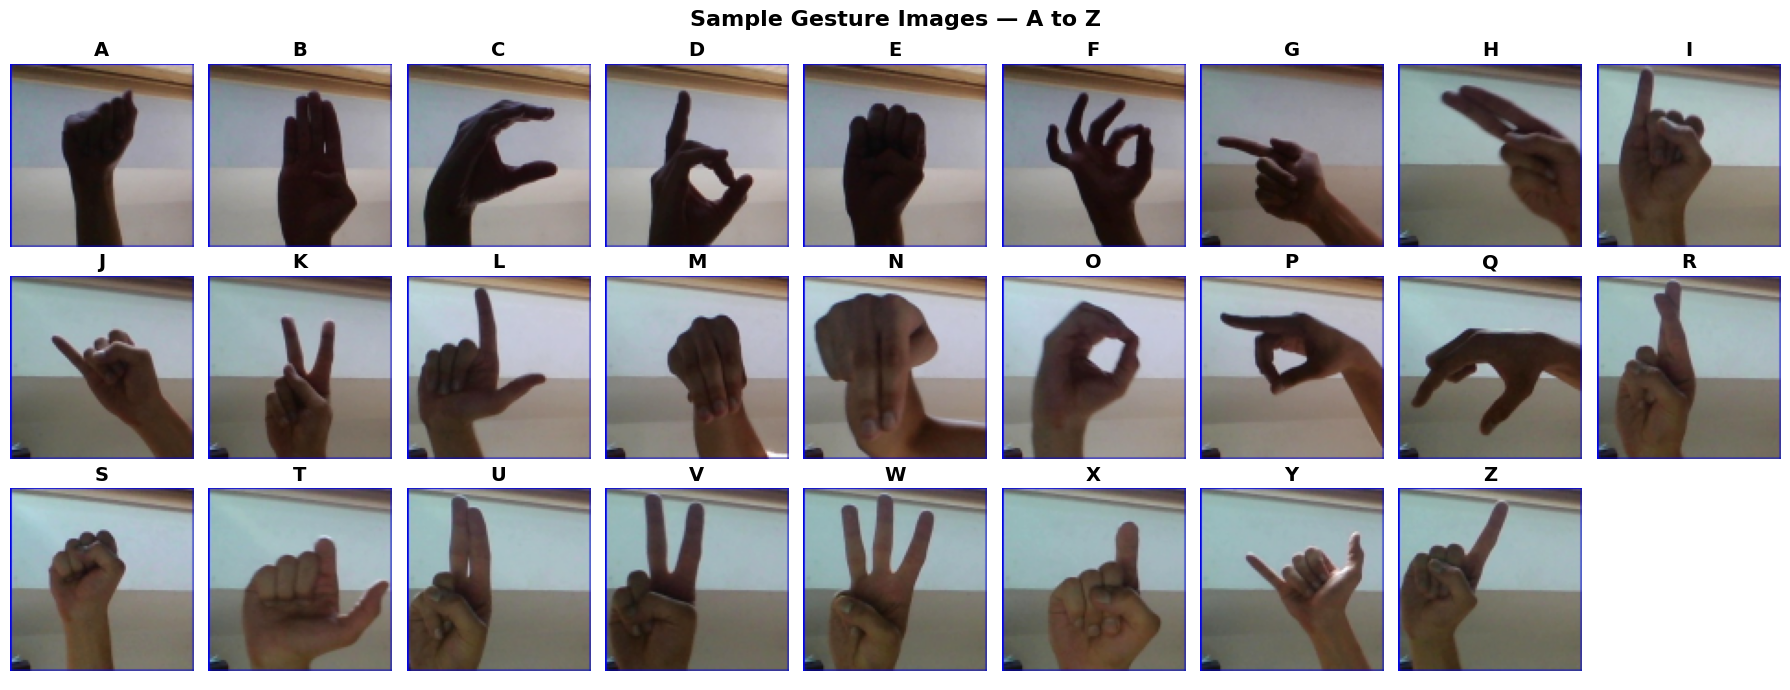

In [10]:
DATASET_PATH = '../data/raw/asl_alphabet_train/asl_alphabet_train'

letters = sorted(os.listdir(DATASET_PATH))
letters = [l for l in letters if l not in ['del', 'nothing', 'space']]

fig, axes = plt.subplots(3, 9, figsize=(18, 7))
axes = axes.flatten()

for i, letter in enumerate(letters):
    letter_path = os.path.join(DATASET_PATH, letter)
    images = os.listdir(letter_path)
    img_path = os.path.join(letter_path, images[0])
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (100, 100))
    axes[i].imshow(img)
    axes[i].set_title(letter, fontsize=14, fontweight='bold')
    axes[i].axis('off')

for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.suptitle('Sample Gesture Images — A to Z', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/sample_images.png', dpi=150)
plt.show()

## Chart 3 — Hand Landmark Visualization
MediaPipe detects 21 points on every hand.
Let's visualize what those points look like.

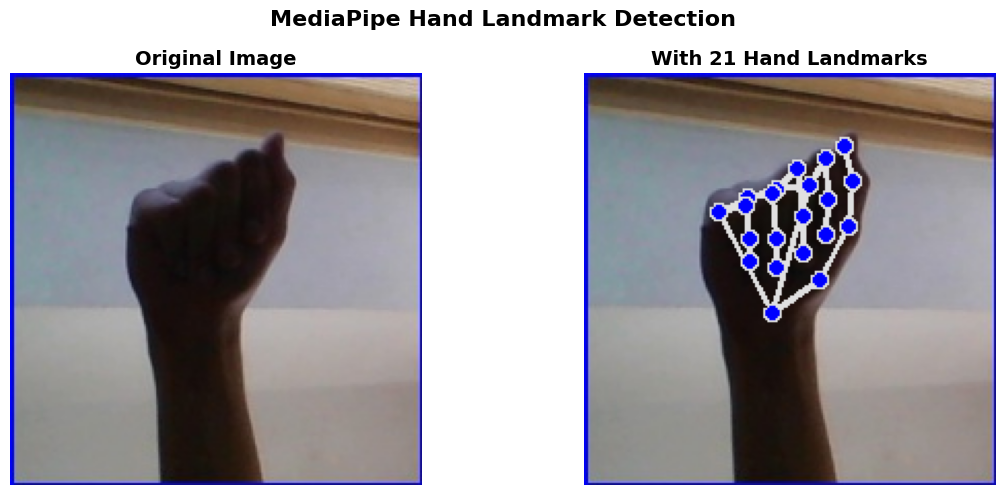

In [11]:
mp_hands = mp.solutions.hands
mp_drawing = mp.solutions.drawing_utils

hands = mp_hands.Hands(
    static_image_mode=True,
    max_num_hands=1,
    min_detection_confidence=0.5
)

sample_img_path = os.path.join(DATASET_PATH, 'A', 'A1.jpg')
image = cv2.imread(sample_img_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

results = hands.process(image_rgb)

annotated = image_rgb.copy()
if results.multi_hand_landmarks:
    for hand_landmarks in results.multi_hand_landmarks:
        mp_drawing.draw_landmarks(
            annotated,
            hand_landmarks,
            mp_hands.HAND_CONNECTIONS
        )

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(image_rgb)
axes[0].set_title('Original Image', fontsize=14, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(annotated)
axes[1].set_title('With 21 Hand Landmarks', fontsize=14, fontweight='bold')
axes[1].axis('off')

plt.suptitle('MediaPipe Hand Landmark Detection', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/landmark_visualization.png', dpi=150)
plt.show()

## Chart 4 — Landmark Coordinate Heatmap
Which landmark coordinates vary the most across different gestures?
High variance = more useful for classification.

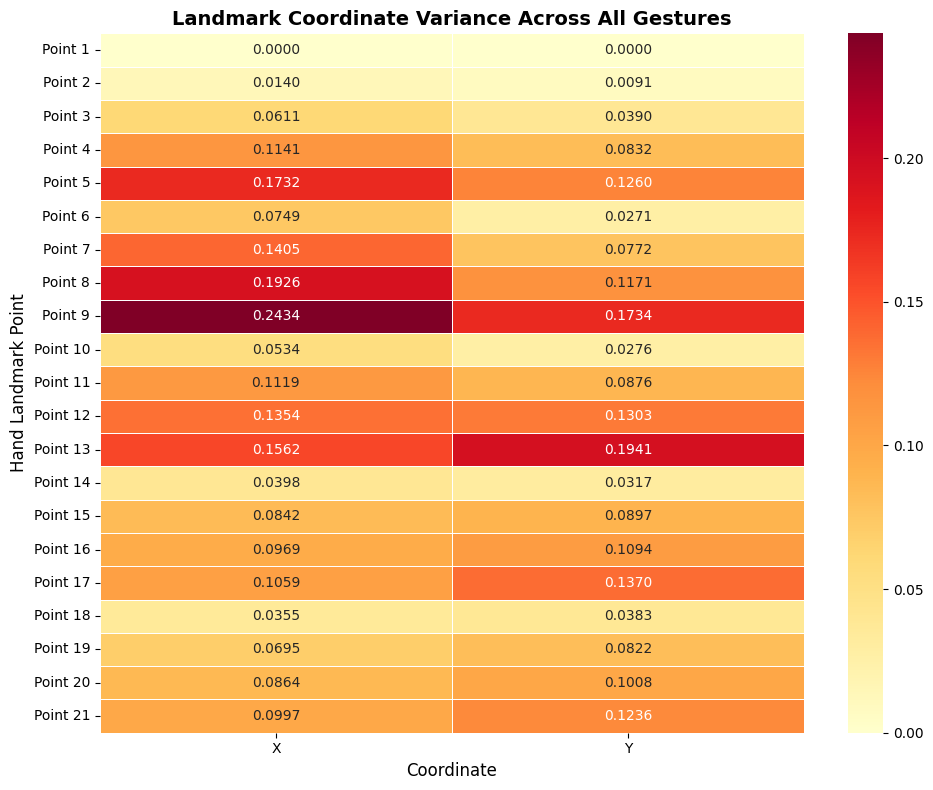

High variance = more useful feature for classification


In [12]:
feature_cols = [col for col in df.columns if col != 'label']

variances = df[feature_cols].var()

variance_matrix = variances.values.reshape(21, 2)

plt.figure(figsize=(10, 8))
sns.heatmap(
    variance_matrix,
    annot=True,
    fmt='.4f',
    cmap='YlOrRd',
    xticklabels=['X', 'Y'],
    yticklabels=[f'Point {i+1}' for i in range(21)],
    linewidths=0.5
)

plt.title('Landmark Coordinate Variance Across All Gestures', fontsize=14, fontweight='bold')
plt.xlabel('Coordinate', fontsize=12)
plt.ylabel('Hand Landmark Point', fontsize=12)
plt.tight_layout()
plt.savefig('../data/processed/landmark_heatmap.png', dpi=150)
plt.show()

print("High variance = more useful feature for classification")